In [10]:
import numpy as np
# from osgeo import gdal
# from osgeo import osr
import os
# import pyresample as pr
# from satpy import Scene
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
# from satpy.readers import find_files_and_readers
# from satpy.readers.core.grouping import find_files_and_readers
import xarray as xr
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

In [2]:
base_path = Path(os.getcwd())
repo_root = base_path.parents[3]
print(f"Current working directory: {base_path}")
print(f"Repository root directory: {repo_root}")

Current working directory: c:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT\Duomenu_mokslo_projektas\code\python\EUMDAC
Repository root directory: c:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT


In [3]:
ds = xr.open_dataset(os.path.join(repo_root, "output.nc"))
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:                     (time: 19130, independent_4: 4, spectral: 4096)
Dimensions without coordinates: time, independent_4, spectral
Data variables: (12/18)
    datetime                    (time) datetime64[ns] 153kB ...
    orbit_index                 int32 4B ...
    latitude                    (time) float64 153kB ...
    longitude                   (time) float64 153kB ...
    latitude_bounds             (time, independent_4) float64 612kB ...
    longitude_bounds            (time, independent_4) float64 612kB ...
    ...                          ...
    cloud_fraction              (time) float64 153kB ...
    solar_zenith_angle_toa      (time) float64 153kB ...
    solar_azimuth_angle_toa     (time) float64 153kB ...
    viewing_zenith_angle_toa    (time) float64 153kB ...
    viewing_azimuth_angle_toa   (time) float64 153kB ...
    index                       (time) int32 77kB ...
Attributes:
    Conventions:     HARP-1.0
    datetime_start:  7

In [4]:
# list all variables
print(list(ds.data_vars))

# access a variable
lat = ds["latitude"].values
lon = ds["longitude"].values
cloud = ds["cloud_fraction"].values

# select one spectrum (time index 0)
spectrum = ds["wavelength_photon_radiance"].isel(time=0).values

['datetime', 'orbit_index', 'latitude', 'longitude', 'latitude_bounds', 'longitude_bounds', 'wavelength_photon_radiance', 'wavelength', 'integration_time', 'scan_subindex', 'scan_direction_type', 'cloud_top_pressure', 'cloud_fraction', 'solar_zenith_angle_toa', 'solar_azimuth_angle_toa', 'viewing_zenith_angle_toa', 'viewing_azimuth_angle_toa', 'index']


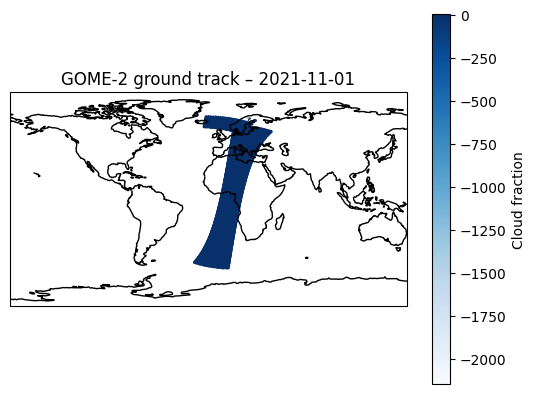

In [5]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
ax.coastlines()
sc = ax.scatter(ds["longitude"], ds["latitude"],
    c=ds["cloud_fraction"], cmap="Blues", s=1)
plt.colorbar(sc, label="Cloud fraction")
plt.title("GOME-2 ground track – 2021-11-01")
plt.show()

In [6]:
for var in ds.data_vars:
    print(f"{var:40s} {str(ds[var].dims):40s} {ds[var].shape}")

datetime                                 ('time',)                                (19130,)
orbit_index                              ()                                       ()
latitude                                 ('time',)                                (19130,)
longitude                                ('time',)                                (19130,)
latitude_bounds                          ('time', 'independent_4')                (19130, 4)
longitude_bounds                         ('time', 'independent_4')                (19130, 4)
wavelength_photon_radiance               ('time', 'spectral')                     (19130, 4096)
wavelength                               ('time', 'spectral')                     (19130, 4096)
integration_time                         ('time', 'spectral')                     (19130, 4096)
scan_subindex                            ('time',)                                (19130,)
scan_direction_type                      ('time',)                           

In [11]:


dt = ds["datetime"].values

print("First datetime:", dt[0])
print("Last datetime: ", dt[-1])
print("Total measurements:", len(dt))

# time differences between consecutive measurements
deltas = np.diff(dt).astype("timedelta64[ms]").astype(float)  # in milliseconds

print("\nTime intervals (ms):")
print(f"  Min:    {deltas.min():.1f} ms")
print(f"  Max:    {deltas.max():.1f} ms")
print(f"  Mean:   {deltas.mean():.1f} ms")
print(f"  Median: {np.median(deltas):.1f} ms")

# check if there are any gaps (intervals much larger than median)
threshold = np.median(deltas) * 10
gaps = np.where(deltas > threshold)[0]
print(f"\nLarge gaps (>{threshold:.0f} ms): {len(gaps)} found")
if len(gaps) > 0:
    for g in gaps:
        print(f"  Between index {g} and {g+1}: {deltas[g]:.0f} ms "
              f"({pd.Timestamp(dt[g])} → {pd.Timestamp(dt[g+1])})")

# unique interval values
unique_intervals = np.unique(deltas.round(0))
print(f"\nUnique interval values (ms): {unique_intervals}")

First datetime: 2021-11-01T08:50:57.722499968
Last datetime:  2021-11-01T10:32:57.492000000
Total measurements: 19130

Time intervals (ms):
  Min:    186.0 ms
  Max:    2532169.0 ms
  Mean:   319.4 ms
  Median: 187.0 ms

Large gaps (>1870 ms): 1 found
  Between index 15932 and 15933: 2532169 ms (2021-11-01 09:40:45.514000 → 2021-11-01 10:22:57.683500032)

Unique interval values (ms): [1.860000e+02 1.870000e+02 3.740000e+02 3.750000e+02 2.532169e+06]


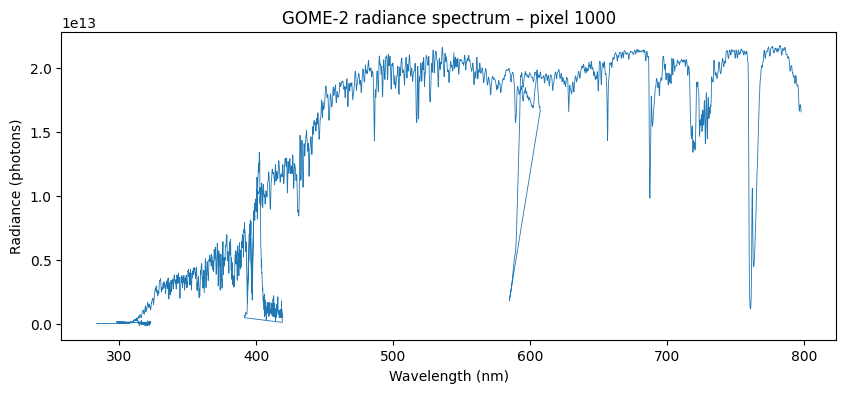

In [7]:
wl  = ds["wavelength"].isel(time=5).values               # (4096,)
rad = ds["wavelength_photon_radiance"].isel(time=5).values  # (4096,)

plt.figure(figsize=(10, 4))
plt.plot(wl, rad, lw=0.6)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance (photons)")
plt.title("GOME-2 radiance spectrum – pixel 1000")
plt.show()

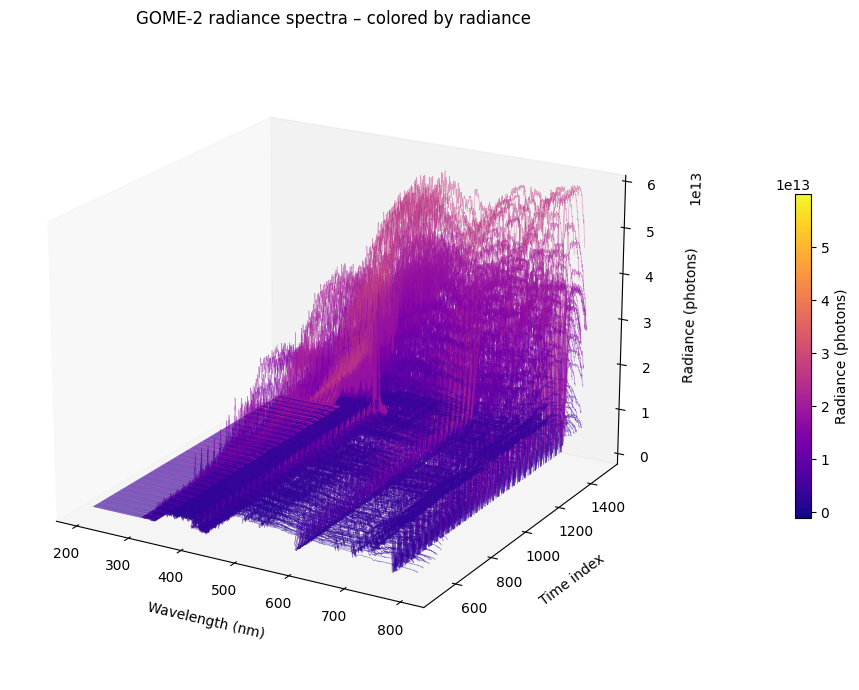

In [8]:
time_slice = slice(500, 1500, 2)
time_indices = np.arange(500, 1500, 2)

wl  = ds["wavelength"].isel(time=time_slice).values
rad = ds["wavelength_photon_radiance"].isel(time=time_slice).values

# normalize radiance for colormap
rad_min, rad_max = rad.min(), rad.max()
norm = plt.Normalize(vmin=rad_min, vmax=rad_max)
cmap = plt.cm.plasma

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection='3d')

for i, t_idx in enumerate(time_indices):
    mean_rad = rad[i].mean()
    ax.plot(wl[i], np.full_like(wl[i], t_idx), rad[i],
            color=cmap(norm(mean_rad)), lw=0.4, alpha=0.5)

ax.set_xlabel("Wavelength (nm)", labelpad=10)
ax.set_ylabel("Time index", labelpad=10)
ax.set_zlabel("Radiance (photons)", labelpad=10)
ax.set_title("GOME-2 radiance spectra – colored by radiance")

ax.view_init(elev=20, azim=-60)
ax.grid(False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.1, label="Radiance (photons)")

plt.tight_layout()
plt.show()

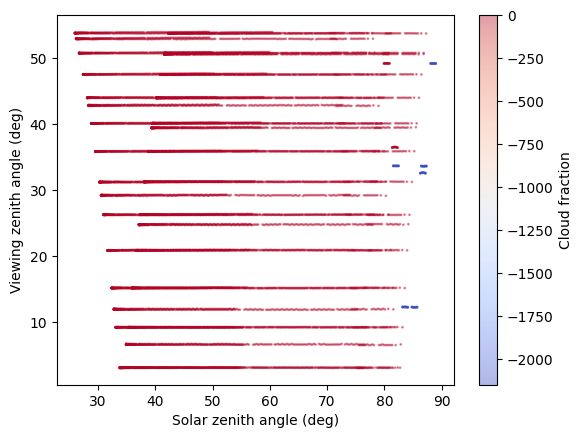

In [9]:
# scatter: viewing angle vs solar angle
plt.scatter(ds["solar_zenith_angle_toa"],
    ds["viewing_zenith_angle_toa"],
    c=ds["cloud_fraction"], cmap="coolwarm",
    s=1, alpha=0.4)
plt.xlabel("Solar zenith angle (deg)")
plt.ylabel("Viewing zenith angle (deg)")
plt.colorbar(label="Cloud fraction")
plt.show()